Libraries Used

In [ ]:
import mne
import numpy as np
import matplotlib.pyplot as plt
import pywt
from scipy.signal import butter, filtfilt
import cv2
from mne import make_fixed_length_epochs
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import confusion_matrix, roc_auc_score
import seaborn as sns
import tensorflow as tf
import random
import time


np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

Determining the channels used for creating multi channel image


In [ ]:
channels = [0, 1, 2]

In [4]:
def bandpass_filter(signal):
    low = 8
    high = 30
    b, a = butter(4, [low/(fs/2), high/(fs/2)], btype='band')
    return filtfilt(b, a, signal)

In [5]:
def generate_scalogram(signal):
    scales = np.arange(1, 64)
    coeffs, _ = pywt.cwt(signal, scales, 'morl', 1/fs)

    scalogram = np.abs(coeffs)

    # Normalize image
    scalogram = (scalogram - np.min(scalogram)) / (np.max(scalogram) - np.min(scalogram))

    # Resize to fixed size (25x25)
    scalogram = cv2.resize(scalogram, (25, 25))

    return scalogram


In [6]:
def register_user(file_path, label):

    raw = mne.io.read_raw_edf(file_path, preload=True)

    epochs = make_fixed_length_epochs(raw, duration=2.0, overlap=1.0)
    epochs_data = epochs.get_data() # shape: (samples, channels, time)

    global fs
    fs = int(raw.info['sfreq'])
    
    X = []
    y = []

    for epoch in epochs_data:

        # Normalize this epoch (per channel)
        epoch = (epoch - np.mean(epoch, axis=1, keepdims=True)) / np.std(epoch, axis=1, keepdims=True)

        # Apply bandpass per channel
        filtered = []
        for ch in epoch:
            filtered.append(bandpass_filter(ch))

        filtered = np.array(filtered)

        # Create multi-channel image
        imgs = []
        for ch in channels:
            scal = generate_scalogram(filtered[ch])
            imgs.append(scal)

        multi_img = np.stack(imgs, axis=-1)

        X.append(multi_img)
        y.append(label)

    return np.array(X), np.array(y)

In [7]:
def authenticate(file_path):

    raw = mne.io.read_raw_edf(file_path, preload=True)

    epochs = make_fixed_length_epochs(raw, duration=2.0, overlap=1.0)
    epochs_data = epochs.get_data()
    
    global fs
    fs = int(raw.info['sfreq'])

    predictions = []

    for epoch in epochs_data:

        epoch = (epoch - np.mean(epoch, axis=1, keepdims=True)) / np.std(epoch, axis=1, keepdims=True)

        filtered = [bandpass_filter(ch) for ch in epoch]
        filtered = np.array(filtered)

        imgs = [generate_scalogram(filtered[ch]) for ch in channels]

        sample = np.stack(imgs, axis=-1)
        sample = np.expand_dims(sample, axis=0)

        pred = model.predict(sample)[0][0]
        predictions.append(pred)

    votes = [1 if p > 0.5 else 0 for p in predictions]

    if sum(votes) > len(votes)/2:
        return "Authorized"
    else:
        return "Unauthorized"

Registering user

In [ ]:
X1, y1 = register_user("data\\S001\\S001R01.edf", 1)
X2, y2 = register_user("data\\S001\\S001R02.edf", 1)
X3, y3 = register_user("data\\S002\\S002R01.edf", 0)  
X4, y4 = register_user("data\\S003\\S003R01.edf", 0) 
X5, y5 = register_user("data\\S004\\S004R01.edf", 0)
X6, y6 = register_user("data\\S005\\S005R01.edf", 0)

X = np.concatenate([X1, X2, X3, X4, X5,X6])
y = np.concatenate([y1, y2, y3, y4, y5, y6])

Deep Learning: CNN is trained over the registered users

In [ ]:
# Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# CNN MODEL

model = Sequential([
    Conv2D(16, (3,3), activation='relu', input_shape=(25,25,3)),
    MaxPooling2D(2,2),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# COMPILE

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# TRAIN

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=45,
    batch_size=8
)

# CONFUSION MATRIX

y_pred = (model.predict(X_test) > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = cm.ravel()

Characteristics of trained model

In [ ]:
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
recall= tp / (tp + fn)
specificity = tn / (tn + fp)
f1 = 2 * (precision * recall) / (precision + recall)
mcc = ((tp * tn) - (fp * fn)) / np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
error_rate = 1 - accuracy
far = fp / (fp + tn)
frr = fn / (fn + tp)

y_prob = model.predict(X_test).ravel()
auc = roc_auc_score(y_test, y_prob)

start = time.time()
_ = model.predict(X_test[:1])
end = time.time()
latency = end - start

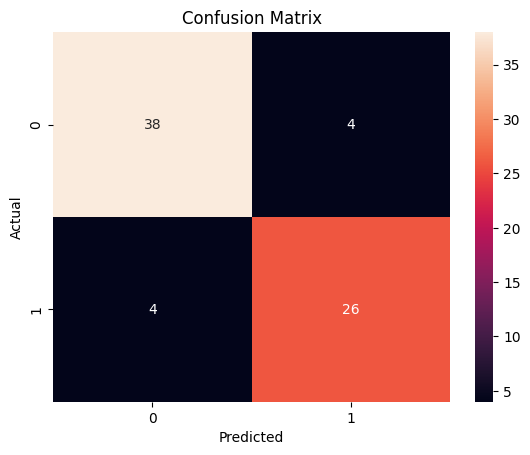


--- PERFORMANCE METRICS ---
Accuracy: 0.8889
Precision: 0.8667
Recall (Sensitivity): 0.8667
Specificity: 0.9048
F1 Score: 0.8667
AUC-ROC: 0.9643
MCC: 0.7714
FAR: 0.0952
FRR: 0.1333
Error Rate: 0.1111
Latency (sec): 0.107648


In [11]:
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\n--- PERFORMANCE METRICS ---")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC-ROC: {auc:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"FAR: {far:.4f}")
print(f"FRR: {frr:.4f}")
print(f"Error Rate: {error_rate:.4f}")
print(f"Latency (sec): {latency:.6f}")

Testing

In [ ]:
print(authenticate("data\\S002\\S002R01.edf"))

Extracting EDF parameters from S002R01.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 9759  =      0.000 ...    60.994 secs...
Not setting metadata
60 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 60 events and 320 original time points ...
0 bad epochs dropped
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━